# **QUANTUM FORGE**





In this notebook, I will build a small hybrid quantum-classical workflow using the Moth Quantum API. First, I will define a simple resource-selection problem where each resource has a value and a cost, and there is a fixed budget. Then, I will connect to the Moth Quantum API and use the graph-v1 QPU to generate candidate configurations. Each measurement bitstring will represent a possible selection of the resources. After getting the measurements from the QPU, I will interpret each bitstring as a candidate solution. I will then use a classical program to check the constraints, calculate the value and cost of each candidate, and remove configurations that exceed the budget. Finally, I will rank the feasible candidates and select the best one as the Forged Result.

In [1]:
#importing and Moth connection
import os
import requests
from google.colab import userdata

API = "https://api.mothquantum.com/api/v1"

moth_api_key = userdata.get('MOTH_API_KEY')

HEADER = {
    "Authorization": f"Bearer {moth_api_key}"
}

In [2]:
#create QPU job
payload = {
    "params": {
        "mode": "qpu",
        "num_qubits": 4,
        "shots": 128,

    }
}

r = requests.post(
    f"{API}/engines/graph-v1/process",
    headers=HEADER,
    json=payload)
r.raise_for_status()
job = r.json()
job


{'$schema': 'https://api.mothquantum.com/schemas/SubmitJobOutputBody.json',
 'job_id': 'e62065c0-266c-4792-bf63-3aed6716f755',
 'status': 'queued',
 'submitted_at': '2026-10-05T04:42:58Z'}

In [5]:
#Polling the job and confirming that the task is completed
import time

job_id = job["job_id"]

while True:
    r = requests.get(f"{API}/jobs/{job_id}/status", headers=HEADER)
    r.raise_for_status()
    status = r.json()

    print(status.get("status"))

    if status.get("status") in {"completed", "failed", "cancelled"}:
        break

    time.sleep(2)

assert status.get("status") == "completed"

processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
completed


In [6]:
#getting the result
r = requests.get(f"{API}/jobs/{job_id}/result", headers=HEADER)
r.raise_for_status()
status = r.json()
result = r.json()
result


{'$schema': 'https://api.mothquantum.com/schemas/JobResultOutputBody.json',
 'result': {'output': {'backend': 'ibm_miami',
   'coupling_map': [[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]],
   'dominant_bitstring': '0011',
   'edge_agreement_score': 0.3333,
   'ibm_job_id': 'db1illmegvvc73bhm5b0',
   'measurements': [{'bitstring': '0011',
     'count': 35,
     'probability': 0.2734375},
    {'bitstring': '0111', 'count': 25, 'probability': 0.1953125},
    {'bitstring': '0010', 'count': 14, 'probability': 0.109375},
    {'bitstring': '0001', 'count': 12, 'probability': 0.09375},
    {'bitstring': '0000', 'count': 11, 'probability': 0.0859375},
    {'bitstring': '0101', 'count': 7, 'probability': 0.0546875},
    {'bitstring': '1111', 'count': 7, 'probability': 0.0546875},
    {'bitstring': '1011', 'count': 6, 'probability': 0.046875},
    {'bitstring': '1010', 'count': 5, 'probability': 0.0390625},
    {'bitstring': '0100', 'count': 2, 'probability': 0.015625},
    {'bitstring': '1101

In [8]:
#Extract candidate
output = result["result"]["output"]
candidates=output["measurements"]
for candidate in candidates:
  print(candidate["bitstring"],candidate["probability"])


0011 0.2734375
0111 0.1953125
0010 0.109375
0001 0.09375
0000 0.0859375
0101 0.0546875
1111 0.0546875
1011 0.046875
1010 0.0390625
0100 0.015625
1101 0.015625
0110 0.0078125
1001 0.0078125


In [9]:
#defining , choosing/ finding a  valid pair
COUPLING_MAP=output["coupling_map"]
def score(bitstring):
  selected = {i for i,bit in enumerate(bitstring) if bit=="1"}
  if len(selected)!=2:
    return -1
  connected = sum(a in selected and b in selected for a,b in COUPLING_MAP)
  return connected

In [10]:
#scoring
for candidate in candidates:
  candidate["score"]=score(candidate["bitstring"])
ranked=sorted(candidates,key=lambda x:x["score"],reverse=True)
for candidate in ranked:
  print(candidate["bitstring"],candidate["score"],candidate["probability"])


0011 1 0.2734375
0101 1 0.0546875
1010 1 0.0390625
0110 1 0.0078125
1001 1 0.0078125
0111 -1 0.1953125
0010 -1 0.109375
0001 -1 0.09375
0000 -1 0.0859375
1111 -1 0.0546875
1011 -1 0.046875
0100 -1 0.015625
1101 -1 0.015625


In [11]:
#Quantum forge

def forge_score(bitstring, coupling_map):
    if bitstring.count("1") != 2:
        return -1

    selected = {i for i, bit in enumerate(bitstring) if bit == "1"}

    return sum(
        a in selected and b in selected
        for a, b in coupling_map
    )

In [12]:
#candidate
coupling_map = output["coupling_map"]

for candidate in candidates:
    candidate["score"] = forge_score(
        candidate["bitstring"],
        coupling_map
    )

ranked = sorted(candidates, key=lambda x: x["score"], reverse=True)

for c in ranked:
    print(
        f"{c['bitstring']}  "
        f"score={c['score']}  "
        f"probability={c['probability']:.3f}"
    )

0011  score=1  probability=0.273
0101  score=1  probability=0.055
1010  score=1  probability=0.039
0110  score=1  probability=0.008
1001  score=1  probability=0.008
0111  score=-1  probability=0.195
0010  score=-1  probability=0.109
0001  score=-1  probability=0.094
0000  score=-1  probability=0.086
1111  score=-1  probability=0.055
1011  score=-1  probability=0.047
0100  score=-1  probability=0.016
1101  score=-1  probability=0.016


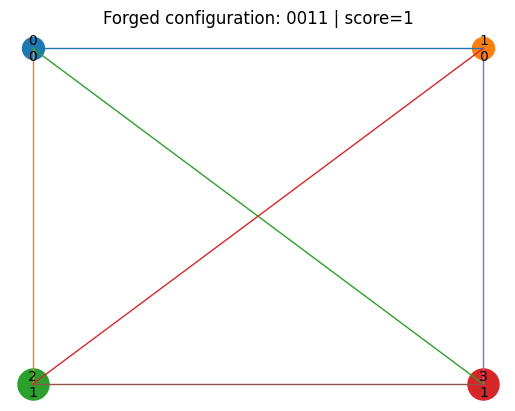

In [16]:
#visualization
import matplotlib.pyplot as plt

best = ranked[0]
bits = best["bitstring"]

positions = {
    0: (0, 1),
    1: (1, 1),
    2: (0, 0),
    3: (1, 0),
}

fig, ax = plt.subplots()

for a, b in coupling_map:
    xa, ya = positions[a]
    xb, yb = positions[b]
    ax.plot([xa, xb], [ya, yb], linewidth=1)

for i, bit in enumerate(bits):
    x, y = positions[i]
    ax.scatter(x, y, s=500 if bit == "1" else 250)
    ax.text(x, y, f"{i}\n{bit}", ha="center", va="center")

ax.set_title(
    f"Forged configuration: {bits} | score={best['score']}"
)
ax.axis("off")
plt.show()

In [17]:

for i, candidate in enumerate(ranked, 1):
    print(
        f"{i:2}. {candidate['bitstring']}  "
        f"score={candidate['score']}  "
        f"probability={candidate['probability']:.2%}"
    )

 1. 0011  score=1  probability=27.34%
 2. 0101  score=1  probability=5.47%
 3. 1010  score=1  probability=3.91%
 4. 0110  score=1  probability=0.78%
 5. 1001  score=1  probability=0.78%
 6. 0111  score=-1  probability=19.53%
 7. 0010  score=-1  probability=10.94%
 8. 0001  score=-1  probability=9.38%
 9. 0000  score=-1  probability=8.59%
10. 1111  score=-1  probability=5.47%
11. 1011  score=-1  probability=4.69%
12. 0100  score=-1  probability=1.56%
13. 1101  score=-1  probability=1.56%


In [18]:
# Quantum Forge problem

values = [9, 7, 6, 5]      # value of each resource
costs = [4, 3, 2, 2]       # cost of each resource
budget = 6

In [19]:
#evaluating
def forge_score(bitstring):
    selected = [i for i, bit in enumerate(bitstring) if bit == "1"]

    total_cost = sum(costs[i] for i in selected)
    total_value = sum(values[i] for i in selected)

    if total_cost > budget:
        return -1, total_cost, total_value

    return total_value, total_cost, total_value


ranked = []

for candidate in candidates:
    score, cost, value = forge_score(candidate["bitstring"])

    ranked.append({
        "bitstring": candidate["bitstring"],
        "probability": candidate["probability"],
        "score": score,
        "cost": cost,
        "value": value
    })

ranked.sort(key=lambda x: x["score"], reverse=True)

for i, c in enumerate(ranked, 1):
    print(
        f"{i:2}. {c['bitstring']}  "
        f"value={c['value']}  "
        f"cost={c['cost']}  "
        f"probability={c['probability']:.2%}"
    )

 1. 1010  value=15  cost=6  probability=3.91%
 2. 1001  value=14  cost=6  probability=0.78%
 3. 0110  value=13  cost=5  probability=0.78%
 4. 0101  value=12  cost=5  probability=5.47%
 5. 0011  value=11  cost=4  probability=27.34%
 6. 0100  value=7  cost=3  probability=1.56%
 7. 0010  value=6  cost=2  probability=10.94%
 8. 0001  value=5  cost=2  probability=9.38%
 9. 0000  value=0  cost=0  probability=8.59%
10. 0111  value=18  cost=7  probability=19.53%
11. 1111  value=27  cost=11  probability=5.47%
12. 1011  value=20  cost=8  probability=4.69%
13. 1101  value=21  cost=9  probability=1.56%


In [20]:
#forge output
best = ranked[0]

selected = [
    i for i, bit in enumerate(best["bitstring"])
    if bit == "1"
]

print("QUANTUM FORGE")
print()
print(f"Forged configuration: {best['bitstring']}")
print(f"Selected resources: {selected}")
print(f"Total value: {best['value']}")
print(f"Total cost: {best['cost']}")
print(f"Budget: {budget}")
print(f"QPU probability: {best['probability']:.2%}")

QUANTUM FORGE

Forged configuration: 1010
Selected resources: [0, 2]
Total value: 15
Total cost: 6
Budget: 6
QPU probability: 3.91%


In [23]:
#making it simple
resources = [
    {"name": "Resource A", "value": 9, "cost": 4},
    {"name": "Resource B", "value": 7, "cost": 3},
    {"name": "Resource C", "value": 6, "cost": 2},
    {"name": "Resource D", "value": 5, "cost": 2},
]

print("FORGED SOLUTION")
print()

for i in selected:
    print(
        f" {resources[i]['name']}  "
        f"(value={resources[i]['value']}, cost={resources[i]['cost']})"
    )

print()
print(f"Total value : {best['value']}")
print(f"Total cost  : {best['cost']}")
print(f"Budget      : {budget}")

FORGED SOLUTION

 Resource A  (value=9, cost=4)
 Resource C  (value=6, cost=2)

Total value : 15
Total cost  : 6
Budget      : 6


In [24]:
#user defined problem (for tjis solar panal + sensor)
resources = [
    {"name": "Solar Panel", "value": 9, "cost": 4},
    {"name": "Battery", "value": 7, "cost": 3},
    {"name": "Sensor", "value": 6, "cost": 2},
    {"name": "Controller", "value": 5, "cost": 2},
]

budget = 6

values = [r["value"] for r in resources]
costs = [r["cost"] for r in resources]

In [26]:
#forge
best = ranked[0]

selected = [
    i for i, bit in enumerate(best["bitstring"])
    if bit == "1"
]

print(" QUANTUM FORGE")
print("=" * 30)

for i in selected:
    r = resources[i]
    print(f"{r['name']}")

print()
print(f"Value      : {best['value']}")
print(f"Cost       : {best['cost']}")
print(f"Budget     : {budget}")
print(f"QPU chance : {best['probability']:.2%}")

 QUANTUM FORGE
Solar Panel
Sensor

Value      : 15
Cost       : 6
Budget     : 6
QPU chance : 3.91%


In [28]:
#forge again
payload = {
    "params": {
        "mode": "qpu",
        "num_qubits": len(resources),
        "shots": 128
    }
}

r = requests.post(
    f"{API}/engines/graph-v1/process",
    headers=HEADER,
    json=payload
)
r.raise_for_status()

job = r.json()
job_id = job["job_id"]

print("Forge job:", job_id)

Forge job: 33752598-1e9e-42a1-a36d-013b224d76f8


In [31]:
#waiting for the forge
import time

while True:
    r = requests.get(
        f"{API}/jobs/{job_id}/status",
        headers=HEADER
    )
    r.raise_for_status()

    status = r.json()
    print(status.get("status"))

    if status.get("status") in {"completed", "failed", "cancelled"}:
        break

    time.sleep(2)

assert status["status"] in {"completed"}

completed


In [33]:

#getting new qqpu result
r = requests.get(
    f"{API}/jobs/{job_id}/result",
    headers=HEADER
)
r.raise_for_status()

result = r.json()
output = result["result"]["output"]

candidates = output["measurements"]

print(f"Generated {len(candidates)} candidate configurations.")

Generated 12 candidate configurations.


In [34]:
#evaluating them
ranked = []

for candidate in candidates:
    score, cost, value = forge_score(candidate["bitstring"])

    if score >= 0:
        ranked.append({
            "bitstring": candidate["bitstring"],
            "probability": candidate["probability"],
            "score": score,
            "cost": cost,
            "value": value
        })

ranked.sort(key=lambda x: x["score"], reverse=True)

for i, c in enumerate(ranked, 1):
    print(
        f"{i:2}. {c['bitstring']}  "
        f"value={c['value']}  "
        f"cost={c['cost']}  "
        f"probability={c['probability']:.2%}"
    )

 1. 1010  value=15  cost=6  probability=3.91%
 2. 0110  value=13  cost=5  probability=2.34%
 3. 0101  value=12  cost=5  probability=4.69%
 4. 0011  value=11  cost=4  probability=33.59%
 5. 0100  value=7  cost=3  probability=0.78%
 6. 0010  value=6  cost=2  probability=10.94%
 7. 0001  value=5  cost=2  probability=6.25%
 8. 0000  value=0  cost=0  probability=0.78%


In [37]:
#final forge result
best = ranked[0]

selected = [
    i for i, bit in enumerate(best["bitstring"])
    if bit == "1"
]

print("QUANTUM FORGE-FORGED RESULT")
print("=" * 38)
print(f"Configuration : {best['bitstring']}")
print()

print("Selected:")
for i in selected:
    print(f"{resources[i]['name']}")

print()
print(f"Total value   : {best['value']}")
print(f"Total cost    : {best['cost']}")
print(f"Budget        : {budget}")
print(f"QPU probability: {best['probability']:.2%}")

QUANTUM FORGE-FORGED RESULT
Configuration : 1010

Selected:
Solar Panel
Sensor

Total value   : 15
Total cost    : 6
Budget        : 6
QPU probability: 3.91%




**Final Result**

  

In this notebook, I tried to build a simple version of Quantum Forge using the Moth Quantum API.

  

I started with a small resource-selection problem. I had four resources: Solar Panel, Battery, Sensor, and Controller. Each one has a value and a cost, and I set the total budget to 6.

  

I used a 4-bit string to represent the selection. For example, "1010" means that the Solar Panel and Sensor are selected.

  

After setting up the problem, I connected to the Moth API and sent a 4-qubit job to the "graph-v1" QPU. The QPU returned different bitstrings with different probabilities. I treated these measured bitstrings as possible solutions to my resource-selection problem.

  

I then checked each of these possibilities using normal Python code. For every bitstring, I calculated its total cost and value. If the cost was greater than the budget, I removed that option. The remaining options were ranked by their value.

  

In the final run, "0011" appeared most often, with a probability of 33.59%. However, its value was only 11. Another configuration, "1010", appeared with a probability of only 3.91%, but it gave a value of 15 while staying exactly within the budget.

So the final result was:

**1010 -> Solar Panel + Sensor**

**Value: 15 **

**Cost: 6 **

**Budget: 6**

This is the main idea I wanted to test with Quantum Forge. Instead of taking the most frequently measured bitstring as the answer, I use the different results from the QPU as possible choices and then check which one works best for the problem I have defined.

In this first version, the resource-selection problem is deliberately small. The QPU is generating the possible configurations, while the classical part of the program is responsible for checking the constraints and choosing the best one.

So, in simple terms, what I built is:

**Define a problem ->generate possible configurations with the Moth QPU ->check those configurations ->choose the best one ->call it the forged result**.

This is the first working prototype of Quantum Forge.